## S-Mobile: Predicting Customer Churn

* Team-lead GitHub userid: rsm-xyz123
* Group name: Group 18
* Team member names: Jin Liu, Jiahui Huang, Shuning Zhang

## Setup

Please complete this python notebook with your group by answering the questions in case07.

Create a Notebook with all your results and comments and push the Notebook to GitHub when your team is done. All results MUST be reproducible (i.e., the TA and I must be able to recreate your output from the Jupyter Notebook without changes or errors). This means that you should NOT use any python-packages that are not part of the RSM-MSBA docker container.

This is a group assignment and you will be using Git and GitHub. If two people edit the same file at the same time you could get what is called a "merge conflict". This is not something serious but you should realize that Git will not decide for you who's changes to accept. The team-lead will have to determine the edits to use. To avoid merge conflicts, **always** "pull" changes to the repo before you start working on any files. Then, when you are done, save and commit your changes, and then push them to GitHub. Make "pull first" a habit!

In [1]:
# update pyrsm to version 2.3.2
!uv --project /opt/base-uv add pyrsm==2.3.2

Resolved 220 packages in 30ms
Audited 203 packages in 13ms


In [2]:
import pyrsm as rsm

print(f"pyrsm version: {rsm.__version__}")

pyrsm version: 2.3.0


In [3]:
import polars as pl
import pyrsm as rsm

In [4]:
## load the data - this dataset must NOT be changed
s_mobile = pl.read_parquet("data/s_mobile.parquet")

In [5]:
rsm.md("data/s_mobile_description.md")

## S-mobile

Dataset used to investigate opportunities to decrease customer churn at S-mobile. The sample consists of three parts:

1. A training sample with 27,300 observations and a 50% churn rate ("training == 1")
2. A test sample with 11,700 observations and a 50% churn rate ("training == 0")
3. A representative sample with 30,000 observations and a churn rate of 2%, i.e., the actual monthly churn rate for S-mobile ("is.na(training)" or "representative == 1")

## Variables

* customer: Customer ID
* churn: Did consumer churn in the last 30 days? (yes or no)
* changer: % change in revenue over the most recent 4 month period
* changem: % change in minutes of use over the most recent 4 month period
* revenue: Mean monthly revenue in SGD
* mou: Mean monthly minutes of use
* overage: Mean monthly overage minutes
* roam: Mean number of roaming calls
* conference: Mean number of conference calls
* months: # of months the customer has had service with S-Mobile
* uniqsubs: Number of individuals listed on the customer account
* custcare: Mean number of calls to customer care
* retcalls: Number of calls by the customer to the retention team
* dropvce: Mean number of dropped voice calls
* eqpdays: Number of days customer has owned current handset
* refurb: Handset is refurbished (no or yes)
* smartphone: Handset is a smartphone (no or yes)
* creditr: High credit rating as opposed to medium or low (no or yes)
* mcycle: Subscriber owns a motorcycle (no or yes)
* car: Subscriber owns a car (no or yes)
* travel: Subscriber has traveled internationally (no or yes)
* region: Regions delineated by the 5 Community Development Council Districts (e.g., CS is Central Singapore)
* occupation: Categorical variable with 4 occupation levels (professional, student, retired, or other)
* training: 1 for training sample, 0 for test sample, NA for representative sample
* representative: 1 for representative sample, 0 for training and test sample


If you want access to the full 1M row dataset, use the code below to download and use the data. Please do **not** include the 1M row dataset in your repo!

The downside to using the dataset with 1M rows is, of course, that estimation time will increase substantially. I do NOT recommend you use this dataset to select your final model or for tuning hyper parameters. You can, however, use this larger dataset to re-estimate your chosen model and generate profit estimates for the representative sample.

In [6]:
s_mobile_1M = pl.read_parquet("data/s_mobile_1M.parquet")
s_mobile_1M

customer,churn,changer,changem,revenue,mou,overage,roam,conference,months,uniqsubs,custcare,retcalls,dropvce,eqpdays,refurb,smartphone,highcreditr,mcycle,car,travel,region,occupation,training,representative
str,cat,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,i32,f64,cat,cat,cat,cat,cat,cat,cat,cat,f64,i32
"""U88927415""","""no""",-1,-8,31,118,1,0,0,38,1,0,0.0,1,493.0,"""no""","""yes""","""no""","""no""","""no""","""no""","""SW""","""other""",0.0,0
"""U94655060""","""no""",0,-2,87,412,104,0,0,10,2,0,0.0,3,448.0,"""no""","""yes""","""no""","""no""","""no""","""yes""","""CS""","""student""",1.0,0
"""U22910834""","""no""",1,23,138,1252,0,3,0,19,4,0,0.0,1,426.0,"""no""","""yes""","""no""","""no""","""no""","""no""","""SE""","""student""",1.0,0
"""U55939985""","""no""",-1,-15,58,69,42,3,0,8,1,1,0.0,2,390.0,"""no""","""yes""","""yes""","""no""","""no""","""no""","""NE""","""other""",null,1
"""U74897690""","""no""",-9,-20,117,1002,175,4,0,11,1,11,0.0,3,267.0,"""yes""","""yes""","""no""","""no""","""no""","""no""","""SE""","""other""",1.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""U63357590""","""no""",2,34,54,778,115,1,1,7,1,11,0.0,4,361.0,"""no""","""yes""","""no""","""no""","""no""","""no""","""NW""","""other""",0.0,0
"""U10548621""","""no""",-5,-20,31,176,40,3,0,35,1,0,0.0,1,1114.0,"""no""","""no""","""no""","""no""","""no""","""no""","""CS""","""retired""",1.0,0
"""U61718563""","""no""",-3,-2,45,1731,105,0,0,30,1,11,0.0,1,828.0,"""no""","""yes""","""no""","""no""","""no""","""no""","""SW""","""other""",1.0,0


## Question answers

#### Q1

##### 1.1 Exploratory Data Analysis

In [7]:
# Dataset shape
s_mobile.shape

# Variable names with data types
list(zip(s_mobile.columns, s_mobile.dtypes))

[('customer', String),
 ('churn', Categorical),
 ('changer', Int32),
 ('changem', Int32),
 ('revenue', Int32),
 ('mou', Int32),
 ('overage', Int32),
 ('roam', Int32),
 ('conference', Int32),
 ('months', Int32),
 ('uniqsubs', Int32),
 ('custcare', Int32),
 ('retcalls', Float64),
 ('dropvce', Int32),
 ('eqpdays', Float64),
 ('refurb', Categorical),
 ('smartphone', Categorical),
 ('highcreditr', Categorical),
 ('mcycle', Categorical),
 ('car', Categorical),
 ('travel', Categorical),
 ('region', Categorical),
 ('occupation', Categorical),
 ('training', Float64),
 ('representative', Int32)]

In [8]:
# Check null counts for all variables
s_mobile.select(
    [pl.col(c).null_count().alias(c) for c in s_mobile.columns]
)

customer,churn,changer,changem,revenue,mou,overage,roam,conference,months,uniqsubs,custcare,retcalls,dropvce,eqpdays,refurb,smartphone,highcreditr,mcycle,car,travel,region,occupation,training,representative
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30000,0


In [9]:
# Check duplicate customer IDs
s_mobile.select(
    pl.col("customer").n_unique().alias("unique_customers"),
    pl.len().alias("total_rows")
)

unique_customers,total_rows
u32,u32
69000,69000


In [10]:
# Check training / representative structure
(
    s_mobile
    .group_by(["training", "representative"])
    .agg(
        pl.len().alias("n_obs")
    )
    .sort(["training", "representative"])
)

training,representative,n_obs
f64,i32,u32
null,1,30000
0.0,0,11700
1.0,0,27300


In [11]:
# Add numeric churn for aggregation
s_mobile_temp = s_mobile.with_columns(
    churn_num = (pl.col("churn") == "yes").cast(pl.Int8)
)

(
    s_mobile_temp
    .group_by(["training", "representative"])
    .agg(
        pl.len().alias("n_obs"),
        pl.col("churn_num").mean().alias("churn_rate")
    )
    .sort(["training", "representative"])
)

training,representative,n_obs,churn_rate
f64,i32,u32,f64
null,1,30000,0.02
0.0,0,11700,0.5
1.0,0,27300,0.5


In [12]:
# Define numeric variables
numeric_cols = [
    "changer", "changem", "revenue", "mou",
    "overage", "roam", "conference",
    "months", "uniqsubs", "custcare",
    "retcalls", "dropvce", "eqpdays"
]

# Quantile structure
for col in numeric_cols:
    print(f"\nVariable: {col}")
    print(
        s_mobile.select(
            pl.col(col).quantile(0.01).alias("p1"),
            pl.col(col).quantile(0.25).alias("p25"),
            pl.col(col).quantile(0.50).alias("median"),
            pl.col(col).quantile(0.75).alias("p75"),
            pl.col(col).quantile(0.99).alias("p99"),
            pl.col(col).min().alias("min"),
            pl.col(col).max().alias("max")
        )
    )


Variable: changer
shape: (1, 7)
┌───────┬──────┬────────┬─────┬───────┬─────┬─────┐
│ p1    ┆ p25  ┆ median ┆ p75 ┆ p99   ┆ min ┆ max │
│ ---   ┆ ---  ┆ ---    ┆ --- ┆ ---   ┆ --- ┆ --- │
│ f64   ┆ f64  ┆ f64    ┆ f64 ┆ f64   ┆ i32 ┆ i32 │
╞═══════╪══════╪════════╪═════╪═══════╪═════╪═════╡
│ -19.0 ┆ -2.0 ┆ 0.0    ┆ 4.0 ┆ 136.0 ┆ -90 ┆ 437 │
└───────┴──────┴────────┴─────┴───────┴─────┴─────┘

Variable: changem
shape: (1, 7)
┌───────┬──────┬────────┬──────┬───────┬─────┬─────┐
│ p1    ┆ p25  ┆ median ┆ p75  ┆ p99   ┆ min ┆ max │
│ ---   ┆ ---  ┆ ---    ┆ ---  ┆ ---   ┆ --- ┆ --- │
│ f64   ┆ f64  ┆ f64    ┆ f64  ┆ f64   ┆ i32 ┆ i32 │
╞═══════╪══════╪════════╪══════╪═══════╪═════╪═════╡
│ -53.0 ┆ -9.0 ┆ -1.0   ┆ 27.0 ┆ 225.0 ┆ -78 ┆ 540 │
└───────┴──────┴────────┴──────┴───────┴─────┴─────┘

Variable: revenue
shape: (1, 7)
┌─────┬──────┬────────┬──────┬───────┬─────┬──────┐
│ p1  ┆ p25  ┆ median ┆ p75  ┆ p99   ┆ min ┆ max  │
│ --- ┆ ---  ┆ ---    ┆ ---  ┆ ---   ┆ --- ┆ ---  │
│ f64 ┆ f6

The quantile analysis indicates that several numerical variables exhibit right-skewed and heavy-tailed distributions, particularly, mou, revenue, changer, changem and eqpdays.

For these variables, the maximum values are substantially larger than the 99th percentile, suggesting the presence of extreme high observations. However, such patterns are consistent with typical telecom usage behavior (e.g., heavy users) rather than data errors.

Several variables such as roam, conference, and retcalls are zero-inflated, with the 75th percentile equal to zero. In these cases, IQR-based outlier detection may overstate anomalies due to the sparse structure of the data.

Variables like months and uniqsubs display relatively stable distributions without extreme tails.

Overall, the extreme values appear to reflect natural distributional characteristics rather than data quality issues. Therefore, no winsorization or trimming is applied at this stage, and all numerical variables are retained for modeling.

In [13]:
# IQR-based outlier detection

for col in numeric_cols:
    
    q1 = s_mobile.select(pl.col(col).quantile(0.25)).item()
    q3 = s_mobile.select(pl.col(col).quantile(0.75)).item()
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_count = (
        s_mobile
        .filter((pl.col(col) < lower) | (pl.col(col) > upper))
        .height
    )
    
    total_count = s_mobile.height
    outlier_ratio = outlier_count / total_count
    
    print(f"\nVariable: {col}")
    print(f"IQR Lower Bound: {lower}")
    print(f"IQR Upper Bound: {upper}")
    print(f"Outlier Count: {outlier_count}")
    print(f"Outlier Ratio: {round(outlier_ratio, 4)}")


Variable: changer
IQR Lower Bound: -11.0
IQR Upper Bound: 13.0
Outlier Count: 15133
Outlier Ratio: 0.2193

Variable: changem
IQR Lower Bound: -63.0
IQR Upper Bound: 81.0
Outlier Count: 5733
Outlier Ratio: 0.0831

Variable: revenue
IQR Lower Bound: -23.5
IQR Upper Bound: 124.5
Outlier Count: 4040
Outlier Ratio: 0.0586

Variable: mou
IQR Lower Bound: -685.5
IQR Upper Bound: 1566.5
Outlier Count: 3538
Outlier Ratio: 0.0513

Variable: overage
IQR Lower Bound: -190.5
IQR Upper Bound: 317.5
Outlier Count: 0
Outlier Ratio: 0.0

Variable: roam
IQR Lower Bound: 0.0
IQR Upper Bound: 0.0
Outlier Count: 13937
Outlier Ratio: 0.202

Variable: conference
IQR Lower Bound: 0.0
IQR Upper Bound: 0.0
Outlier Count: 10485
Outlier Ratio: 0.152

Variable: months
IQR Lower Bound: -8.5
IQR Upper Bound: 43.5
Outlier Count: 1591
Outlier Ratio: 0.0231

Variable: uniqsubs
IQR Lower Bound: -0.5
IQR Upper Bound: 3.5
Outlier Count: 2511
Outlier Ratio: 0.0364

Variable: custcare
IQR Lower Bound: -4.5
IQR Upper Bound:

Although several variables show high IQR-based outlier ratios, this appears to reflect natural skewness and zero-inflation rather than data errors. Therefore, no winsorization or trimming is applied at this stage.

/tmp/ipykernel_77112/3980926448.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot([no, yes], labels=["No Churn", "Churn"])
/tmp/ipykernel_77112/3980926448.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot([no, yes], labels=["No Churn", "Churn"])
/tmp/ipykernel_77112/3980926448.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot([no, yes], labels=["No Churn", "Churn"])
/tmp/ipykernel_77112/3980926448.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be

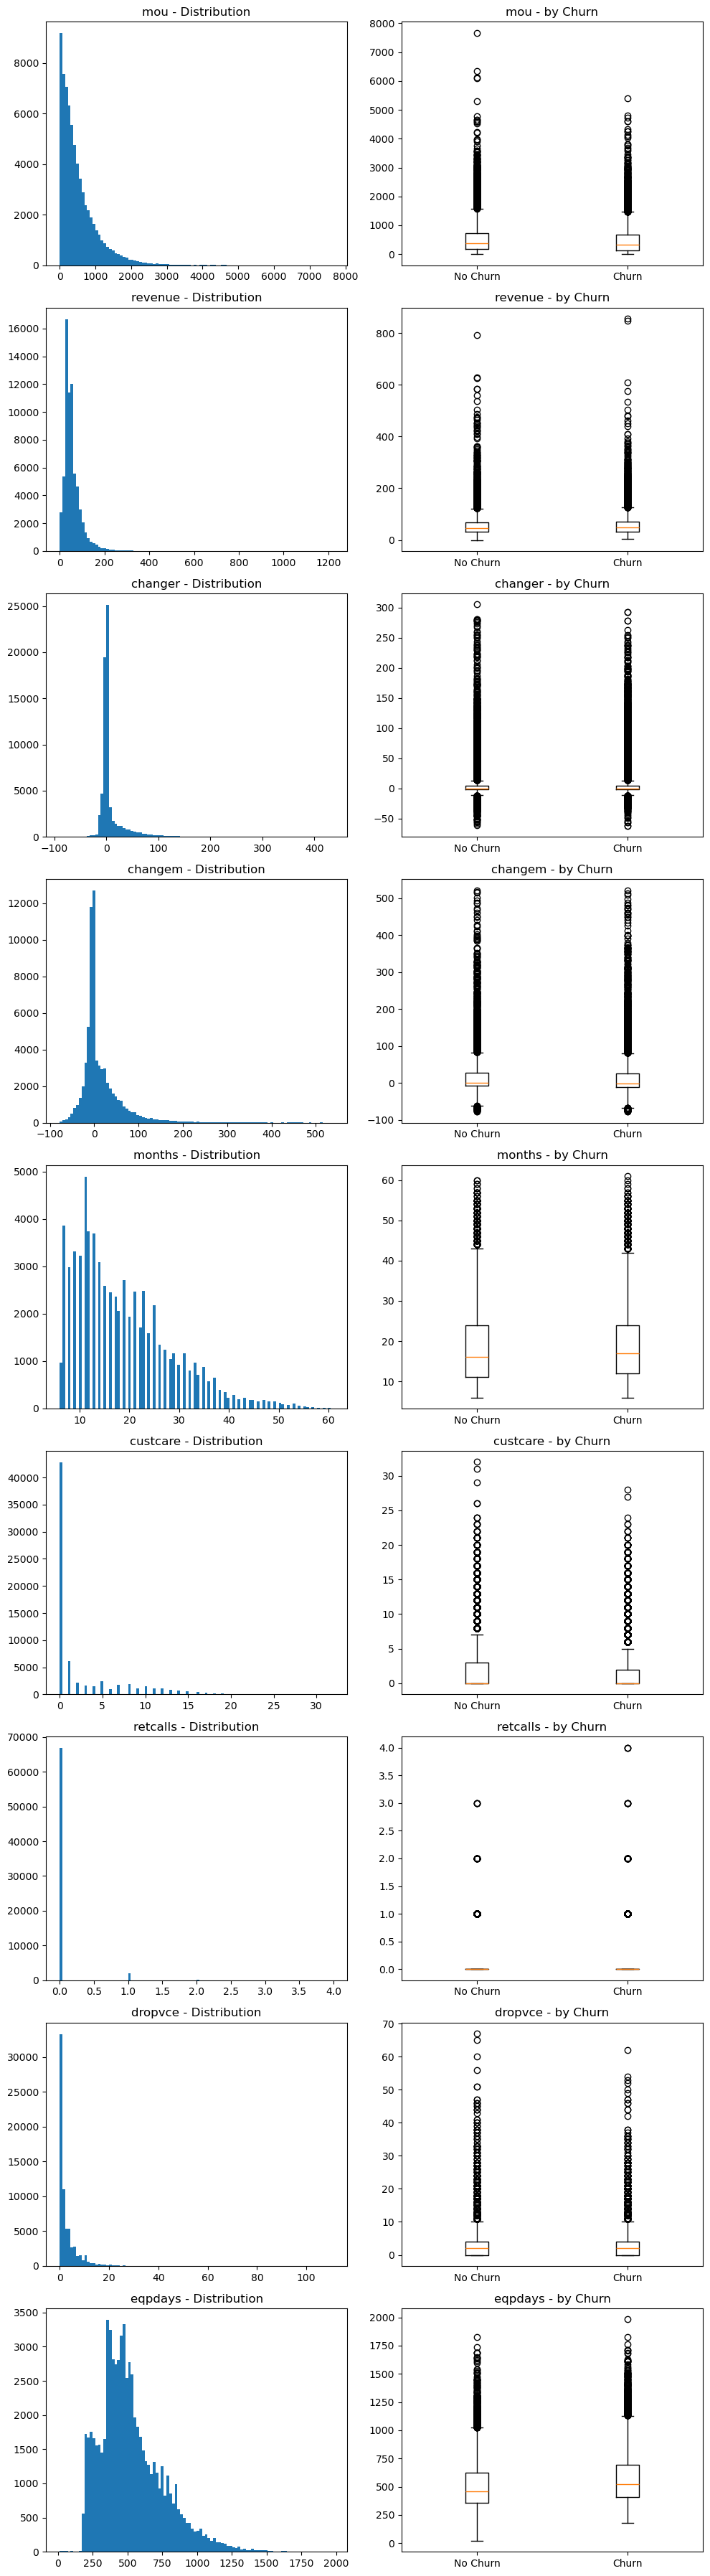

In [14]:
import matplotlib.pyplot as plt
import numpy as np

train_temp = s_mobile.filter(pl.col("training") == 1)

key_vars = [
    "mou", "revenue", "changer", "changem", "months",
    "custcare", "retcalls", "dropvce", "eqpdays"
]

fig, axes = plt.subplots(len(key_vars), 2, figsize=(10, 4*len(key_vars)))

for i, var in enumerate(key_vars):
    
    # Overall distribution
    data = s_mobile[var].to_numpy()
    axes[i, 0].hist(data, bins=100)
    axes[i, 0].set_title(f"{var} - Distribution")
    
    # By churn boxplot
    yes = train_temp.filter(pl.col("churn") == "yes")[var].to_numpy()
    no  = train_temp.filter(pl.col("churn") == "no")[var].to_numpy()
    
    axes[i, 1].boxplot([no, yes], labels=["No Churn", "Churn"])
    axes[i, 1].set_title(f"{var} - by Churn")

plt.tight_layout()
plt.show()

The distributions confirm strong right-skewness and heavy tails in variables such as mou, revenue, changer, and changem, reflecting natural telecom usage patterns rather than data errors.

Boxplots indicate that behavioral variables (custcare, retcalls, dropvce) show clearer separation between churners and non-churners compared to static usage variables. Change-related variables (changer, changem) also exhibit greater dispersion among churners.

Overall, behavioral and usage-change variables appear more informative for churn prediction, and no transformation or trimming is applied at this stage.

In [15]:
# Numeric variables
numeric_cols = [
    "changer", "changem", "revenue", "mou",
    "overage", "roam", "conference",
    "months", "uniqsubs", "custcare",
    "retcalls", "dropvce", "eqpdays"
]

corr_matrix = (
    s_mobile
    .select(numeric_cols)
    .to_pandas()
    .corr()
)

corr_matrix

,changer,changem,revenue,mou,overage,roam,conference,months,uniqsubs,custcare,retcalls,dropvce,eqpdays
changer,1.000000,0.410062,0.107942,0.068935,0.218592,0.023826,0.018732,-0.037496,0.002851,0.023780,0.005444,0.027436,-0.060257
changem,0.410062,1.000000,-0.015116,-0.064465,0.006937,-0.006031,-0.018796,-0.007174,0.003714,-0.048600,-0.007980,-0.068100,-0.011464
revenue,0.107942,-0.015116,1.000000,0.704275,0.562382,0.290932,0.201157,-0.000712,-0.017986,0.242573,0.016938,0.435220,-0.216022
mou,0.068935,-0.064465,0.704275,1.000000,0.529901,0.110639,0.293922,-0.067256,-0.036169,0.470431,0.014219,0.598463,-0.308067
overage,0.218592,0.006937,0.562382,0.529901,1.000000,0.051951,0.148996,-0.026864,-0.016769,0.244749,0.019652,0.333862,-0.156627
roam,0.023826,-0.006031,0.290932,0.110639,0.051951,1.000000,0.019597,-0.008589,-0.004887,0.028338,-0.002036,0.068705,-0.028202
conference,0.018732,-0.018796,0.201157,0.293922,0.148996,0.019597,1.000000,-0.053195,-0.022126,0.225100,0.011791,0.270589,-0.105664
months,-0.037496,-0.007174,-0.000712,-0.067256,-0.026864,-0.008589,-0.053195,1.000000,0.021264,-0.140059,0.068240,-0.043132,0.449924
uniqsubs,0.002851,0.003714,-0.017986,-0.036169,-0.016769,-0.004887,-0.022126,0.021264,1.000000,-0.096530,-0.009576,-0.025948,-0.023111
custcare,0.023780,-0.048600,0.242573,0.470431,0.244749,0.028338,0.225100,-0.140059,-0.096530,1.000000,0.034505,0.358695,-0.231690


Correlation analysis reveals that most numerical variables are weakly correlated. The only relatively strong association is between revenue and minutes of use (r ≈ 0.70), which is expected given their structural relationship. No evidence of severe multicollinearity (|r| > 0.8) is observed, and therefore all variables are retained for modeling.

In [16]:
# Define categorical variables
categorical_vars = [
    "refurb", "smartphone", "highcreditr",
    "mcycle", "car", "travel",
    "region", "occupation"
]

# Category frequency structure
for var in categorical_vars:
    print(f"\nVariable: {var}")
    print(
        s_mobile
        .group_by(var)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
    )


Variable: refurb
shape: (2, 2)
┌────────┬───────┐
│ refurb ┆ count │
│ ---    ┆ ---   │
│ cat    ┆ u32   │
╞════════╪═══════╡
│ no     ┆ 59391 │
│ yes    ┆ 9609  │
└────────┴───────┘

Variable: smartphone
shape: (2, 2)
┌────────────┬───────┐
│ smartphone ┆ count │
│ ---        ┆ ---   │
│ cat        ┆ u32   │
╞════════════╪═══════╡
│ yes        ┆ 62348 │
│ no         ┆ 6652  │
└────────────┴───────┘

Variable: highcreditr
shape: (2, 2)
┌─────────────┬───────┐
│ highcreditr ┆ count │
│ ---         ┆ ---   │
│ cat         ┆ u32   │
╞═════════════╪═══════╡
│ no          ┆ 58136 │
│ yes         ┆ 10864 │
└─────────────┴───────┘

Variable: mcycle
shape: (2, 2)
┌────────┬───────┐
│ mcycle ┆ count │
│ ---    ┆ ---   │
│ cat    ┆ u32   │
╞════════╪═══════╡
│ no     ┆ 56048 │
│ yes    ┆ 12952 │
└────────┴───────┘

Variable: car
shape: (2, 2)
┌─────┬───────┐
│ car ┆ count │
│ --- ┆ ---   │
│ cat ┆ u32   │
╞═════╪═══════╡
│ no  ┆ 62733 │
│ yes ┆ 6267  │
└─────┴───────┘

Variable: travel
shape: (

In [17]:
# Add numeric churn for aggregation (if not already created)
s_mobile_temp = s_mobile.with_columns(
    churn_num = (pl.col("churn") == "yes").cast(pl.Int8)
)

# Churn rate by category
for var in categorical_vars:
    print(f"\nVariable: {var}")
    print(
        s_mobile_temp
        .group_by(var)
        .agg(
            pl.len().alias("n_obs"),
            pl.col("churn_num").mean().alias("churn_rate")
        )
        .sort("churn_rate", descending=True)
    )


Variable: refurb
shape: (2, 3)
┌────────┬───────┬────────────┐
│ refurb ┆ n_obs ┆ churn_rate │
│ ---    ┆ ---   ┆ ---        │
│ cat    ┆ u32   ┆ f64        │
╞════════╪═══════╪════════════╡
│ yes    ┆ 9609  ┆ 0.32532    │
│ no     ┆ 59391 ┆ 0.285801   │
└────────┴───────┴────────────┘

Variable: smartphone
shape: (2, 3)
┌────────────┬───────┬────────────┐
│ smartphone ┆ n_obs ┆ churn_rate │
│ ---        ┆ ---   ┆ ---        │
│ cat        ┆ u32   ┆ f64        │
╞════════════╪═══════╪════════════╡
│ no         ┆ 6652  ┆ 0.376729   │
│ yes        ┆ 62348 ┆ 0.28219    │
└────────────┴───────┴────────────┘

Variable: highcreditr
shape: (2, 3)
┌─────────────┬───────┬────────────┐
│ highcreditr ┆ n_obs ┆ churn_rate │
│ ---         ┆ ---   ┆ ---        │
│ cat         ┆ u32   ┆ f64        │
╞═════════════╪═══════╪════════════╡
│ no          ┆ 58136 ┆ 0.313506   │
│ yes         ┆ 10864 ┆ 0.172496   │
└─────────────┴───────┴────────────┘

Variable: mcycle
shape: (2, 3)
┌────────┬───────┬─────

Most categorical variables exhibit balanced group sizes without severe sparsity issues.

Clear churn differences are observed in:

-Occupation (students show substantially higher churn, retired customers much lower)

-Region (Central Singapore shows elevated churn rates)

-Smartphone ownership (non-smartphone users churn more)

-Credit rating (low-credit customers churn more)

-Refurbished handset users exhibit higher churn.

In contrast, variables such as motorcycle ownership, car ownership, and travel history show minimal churn differentiation.

These findings suggest that demographic and device-related factors contribute meaningfully to churn behavior.

In [18]:
# Work only on training sample
train_temp = s_mobile.filter(pl.col("training") == 1)

# Add numeric churn
train_temp = train_temp.with_columns(
    churn_num = (pl.col("churn") == "yes").cast(pl.Int8)
)

# Compute group means
group_means = (
    train_temp
    .group_by("churn_num")
    .agg([pl.col(c).mean().alias(c) for c in numeric_cols])
    .sort("churn_num")
)

group_means

churn_num,changer,changem,revenue,mou,overage,roam,conference,months,uniqsubs,custcare,retcalls,dropvce,eqpdays
i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,8.181099,16.423297,56.828278,544.960147,61.431575,1.061685,0.290403,18.560952,1.520366,2.503004,0.028571,3.041905,509.116996
1,9.141392,13.999487,57.593993,485.684469,71.116996,1.332821,0.236557,19.002051,1.572088,2.07326,0.056484,2.850769,568.148132


In [19]:
# Compute pooled standard deviation manually

import numpy as np

results = []

for col in numeric_cols:
    
    churn_yes = train_temp.filter(pl.col("churn_num") == 1)[col].to_numpy()
    churn_no  = train_temp.filter(pl.col("churn_num") == 0)[col].to_numpy()
    
    mean_yes = churn_yes.mean()
    mean_no  = churn_no.mean()
    
    std_yes = churn_yes.std()
    std_no  = churn_no.std()
    
    # pooled std
    pooled_std = np.sqrt((std_yes**2 + std_no**2) / 2)
    
    # standardized difference
    std_diff = (mean_yes - mean_no) / pooled_std if pooled_std != 0 else 0
    
    results.append((col, mean_yes, mean_no, std_diff))

results

[('changer',
  np.float64(9.141391941391941),
  np.float64(8.1810989010989),
  np.float64(0.0331680962505628)),
 ('changem',
  np.float64(13.99948717948718),
  np.float64(16.423296703296703),
  np.float64(-0.04672811869381526)),
 ('revenue',
  np.float64(57.59399267399267),
  np.float64(56.82827838827839),
  np.float64(0.017701731324798353)),
 ('mou',
  np.float64(485.68446886446884),
  np.float64(544.9601465201465),
  np.float64(-0.11298938981076022)),
 ('overage',
  np.float64(71.11699633699634),
  np.float64(61.43157509157509),
  np.float64(0.1401910900627635)),
 ('roam',
  np.float64(1.3328205128205128),
  np.float64(1.0616849816849816),
  np.float64(0.0373829129412536)),
 ('conference',
  np.float64(0.23655677655677657),
  np.float64(0.2904029304029304),
  np.float64(-0.04969451286429931)),
 ('months',
  np.float64(19.002051282051283),
  np.float64(18.56095238095238),
  np.float64(0.045981792281516)),
 ('uniqsubs',
  np.float64(1.572087912087912),
  np.float64(1.5203663003663004),

In [20]:
sorted_results = sorted(results, key=lambda x: abs(x[3]), reverse=True)
sorted_results

[('eqpdays',
  np.float64(568.1481318681318),
  np.float64(509.11699633699635),
  np.float64(0.25604154970268295)),
 ('overage',
  np.float64(71.11699633699634),
  np.float64(61.43157509157509),
  np.float64(0.1401910900627635)),
 ('retcalls',
  np.float64(0.05648351648351648),
  np.float64(0.02857142857142857),
  np.float64(0.1258773239709425)),
 ('mou',
  np.float64(485.68446886446884),
  np.float64(544.9601465201465),
  np.float64(-0.11298938981076022)),
 ('custcare',
  np.float64(2.0732600732600734),
  np.float64(2.503003663003663),
  np.float64(-0.10262819146053768)),
 ('uniqsubs',
  np.float64(1.572087912087912),
  np.float64(1.5203663003663004),
  np.float64(0.05807112027496409)),
 ('conference',
  np.float64(0.23655677655677657),
  np.float64(0.2904029304029304),
  np.float64(-0.04969451286429931)),
 ('changem',
  np.float64(13.99948717948718),
  np.float64(16.423296703296703),
  np.float64(-0.04672811869381526)),
 ('months',
  np.float64(19.002051282051283),
  np.float64(18.56

Standardized difference analysis indicates that no numerical variable exhibits a strong effect size (|d| > 0.3).

The largest effect is observed for eqpdays (0.256), followed by overage and retcalls.

Variables such as revenue and changer show very small standardized differences, suggesting limited standalone discriminatory power.

Overall, numerical variables appear to provide moderate but not dominant predictive signals compared to categorical variables.

#### Preliminary Modeling Decisions

Based on the EDA findings:

1. No log transformation is applied despite moderate skewness in certain variables, as the skewness reflects natural telecom behavior rather than data anomalies.

2. Winsorization is not performed, since extreme values represent legitimate heavy users rather than measurement errors.

3. No extreme-value indicator variables are created at this stage.

4. No variables are removed, as no severe multicollinearity is detected.

5. Potential interaction effects are noted but will not be introduced in the baseline model.

All variables are retained for initial modeling.

##### 1.2 Build Model

##### 1.2.1 Logistic Regression

In [21]:
# Define samples
train = s_mobile.filter(pl.col("training") == 1)
valid = s_mobile.filter(pl.col("training") == 0)
rep   = s_mobile.filter(pl.col("representative") == 1)

# Add numeric churn
train = train.with_columns(
    churn_num = (pl.col("churn") == "yes").cast(pl.Int8)
)

valid = valid.with_columns(
    churn_num = (pl.col("churn") == "yes").cast(pl.Int8)
)

rep = rep.with_columns(
    churn_num = (pl.col("churn") == "yes").cast(pl.Int8)
)

In [22]:
exclude = ["customer", "churn", "training", "representative", "churn_num"]

features = [c for c in train.columns if c not in exclude]

In [23]:
formula = "churn_num ~ " + " + ".join(features)

In [24]:
logit = rsm.model.regress(
    data=train,
    formula=formula
)

In [25]:
valid_pred = logit.predict(valid)

In [26]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    valid["churn_num"],
    valid_pred["prediction"]
)

print("Validation AUC:", auc)

Validation AUC: 0.6946807801884725


In [27]:
logit.summary()

Linear regression (OLS)
Data                 : Not provided
Response variable    : churn_num
Explanatory variables: changer, changem, revenue, mou, overage, roam, conference, months, uniqsubs, custcare, retcalls, dropvce, eqpdays, refurb, smartphone, highcreditr, mcycle, car, travel, region, occupation
Null hyp.: the effect of x on churn_num is zero
Alt. hyp.: the effect of x on churn_num is not zero

┌──────────────────────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index                    ┆ coefficient ┆ std.error ┆ t.value ┆ p.value ┆     │
╞══════════════════════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept                ┆ -0.148      ┆ 0.019     ┆ -7.753  ┆ < .001  ┆ *** │
│ refurb[yes]              ┆ 0.067       ┆ 0.008     ┆ 7.988   ┆ < .001  ┆ *** │
│ smartphone[no]           ┆ 0.02        ┆ 0.01      ┆ 1.931   ┆ 0.053   ┆ .   │
│ highcreditr[no]          ┆ 0.156       ┆ 0.009     ┆ 18.074  ┆ < .001  ┆ *** │
│ mcycle[no]               ┆

In [28]:
exclude = ["customer", "churn", "training", "representative", "churn_num"]

features_full = [c for c in train.columns if c not in exclude]

drop_vars = ["car"]

features_reduced = [c for c in features_full if c not in drop_vars]

formula_reduced = "churn_num ~ " + " + ".join(features_reduced)

print(formula_reduced)

churn_num ~ changer + changem + revenue + mou + overage + roam + conference + months + uniqsubs + custcare + retcalls + dropvce + eqpdays + refurb + smartphone + highcreditr + mcycle + travel + region + occupation


In [29]:
logit_reduced = rsm.model.regress(
    data=train,
    formula=formula_reduced
)

valid_pred_reduced = logit_reduced.predict(valid)

auc_reduced = roc_auc_score(
    valid["churn_num"],
    valid_pred_reduced["prediction"]
)

print("Original AUC:", auc)
print("Reduced AUC:", auc_reduced)

Original AUC: 0.6946807801884725
Reduced AUC: 0.6946785886478194


In [30]:
logit_reduced.summary()

Linear regression (OLS)
Data                 : Not provided
Response variable    : churn_num
Explanatory variables: changer, changem, revenue, mou, overage, roam, conference, months, uniqsubs, custcare, retcalls, dropvce, eqpdays, refurb, smartphone, highcreditr, mcycle, travel, region, occupation
Null hyp.: the effect of x on churn_num is zero
Alt. hyp.: the effect of x on churn_num is not zero

┌──────────────────────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index                    ┆ coefficient ┆ std.error ┆ t.value ┆ p.value ┆     │
╞══════════════════════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept                ┆ -0.148      ┆ 0.018     ┆ -8.116  ┆ < .001  ┆ *** │
│ refurb[yes]              ┆ 0.067       ┆ 0.008     ┆ 7.988   ┆ < .001  ┆ *** │
│ smartphone[no]           ┆ 0.02        ┆ 0.01      ┆ 1.932   ┆ 0.053   ┆ .   │
│ highcreditr[no]          ┆ 0.156       ┆ 0.009     ┆ 18.076  ┆ < .001  ┆ *** │
│ mcycle[no]               ┆ 0.02

In [31]:
formula_inter = formula_reduced + " + mou:dropvce"

print(formula_inter)

churn_num ~ changer + changem + revenue + mou + overage + roam + conference + months + uniqsubs + custcare + retcalls + dropvce + eqpdays + refurb + smartphone + highcreditr + mcycle + travel + region + occupation + mou:dropvce


In [32]:
logit_inter = rsm.model.regress(
    data=train,
    formula=formula_inter
)

In [33]:
valid_pred_inter = logit_inter.predict(valid)

auc_inter = roc_auc_score(
    valid["churn_num"],
    valid_pred_inter["prediction"]
)

print("Baseline AUC:", auc_reduced)
print("Interaction AUC:", auc_inter)

Baseline AUC: 0.6946785886478194
Interaction AUC: 0.6946411571334647


In [34]:
logit_inter.summary()

Linear regression (OLS)
Data                 : Not provided
Response variable    : churn_num
Explanatory variables: changer, changem, revenue, mou, overage, roam, conference, months, uniqsubs, custcare, retcalls, dropvce, eqpdays, refurb, smartphone, highcreditr, mcycle, travel, region, occupation
Null hyp.: the effect of x on churn_num is zero
Alt. hyp.: the effect of x on churn_num is not zero

┌──────────────────────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index                    ┆ coefficient ┆ std.error ┆ t.value ┆ p.value ┆     │
╞══════════════════════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept                ┆ -0.146      ┆ 0.018     ┆ -7.911  ┆ < .001  ┆ *** │
│ refurb[yes]              ┆ 0.067       ┆ 0.008     ┆ 7.988   ┆ < .001  ┆ *** │
│ smartphone[no]           ┆ 0.02        ┆ 0.01      ┆ 1.908   ┆ 0.056   ┆ .   │
│ highcreditr[no]          ┆ 0.156       ┆ 0.009     ┆ 18.063  ┆ < .001  ┆ *** │
│ mcycle[no]               ┆ 0.02

In [ ]:
exclude = ["customer", "churn", "training", "representative", "churn_num"]
features_full = [c for c in train.columns if c not in exclude]

drop_vars = ["car"]
features_reduced = [c for c in features_full if c not in drop_vars]

formula_reduced = "churn_num ~ " + " + ".join(features_reduced)

formula_inter2 = formula_reduced + " + occupation:smartphone"

print(formula_inter2)

churn_num ~ changer + changem + revenue + mou + overage + roam + conference + months + uniqsubs + custcare + retcalls + dropvce + eqpdays + refurb + smartphone + highcreditr + mcycle + travel + region + occupation + occupation:smartphone


In [36]:
logit_inter2 = rsm.model.regress(
    data=train,
    formula=formula_inter2
)

In [37]:
valid_pred_inter2 = logit_inter2.predict(valid)

auc_inter2 = roc_auc_score(
    valid["churn_num"],
    valid_pred_inter2["prediction"]
)

print("Baseline AUC:", auc_reduced)
print("Interaction AUC:", auc_inter2)

Baseline AUC: 0.6946785886478194
Interaction AUC: 0.6947524873986413


In [38]:
logit_inter2.summary()

Linear regression (OLS)
Data                 : Not provided
Response variable    : churn_num
Explanatory variables: changer, changem, revenue, mou, overage, roam, conference, months, uniqsubs, custcare, retcalls, dropvce, eqpdays, refurb, smartphone, highcreditr, mcycle, travel, region, occupation
Null hyp.: the effect of x on churn_num is zero
Alt. hyp.: the effect of x on churn_num is not zero

┌─────────────────────────────────────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index                                   ┆ coefficient ┆ std.error ┆ t.value ┆ p.value ┆     │
╞═════════════════════════════════════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept                               ┆ -0.146      ┆ 0.019     ┆ -7.873  ┆ < .001  ┆ *** │
│ refurb[yes]                             ┆ 0.067       ┆ 0.008     ┆ 7.987   ┆ < .001  ┆ *** │
│ smartphone[no]                          ┆ 0.008       ┆ 0.031     ┆ 0.263   ┆ 0.793   ┆     │
│ highcreditr[no]       

##### 1.2.2 Random Forest

In [42]:
train_pd = train.to_pandas()
valid_pd = valid.to_pandas()

In [43]:
X_train = train_pd.drop(columns=["customer", "churn", "training", "representative", "churn_num"])
y_train = train_pd["churn_num"]

X_valid = valid_pd.drop(columns=["customer", "churn", "training", "representative", "churn_num"])
y_valid = valid_pd["churn_num"]

In [44]:
import pandas as pd

X_train = pd.get_dummies(X_train, drop_first=True)
X_valid = pd.get_dummies(X_valid, drop_first=True)

X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [46]:
from sklearn.metrics import roc_auc_score

rf_pred = rf.predict_proba(X_valid)[:, 1]

auc_rf = roc_auc_score(y_valid, rf_pred)

print("Logistic AUC:", auc)
print("Random Forest AUC:", auc_rf)

Logistic AUC: 0.6946807801884725
Random Forest AUC: 0.6928751552341295


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
import numpy as np

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best CV AUC:", rf_search.best_score_)
print("Best Params:", rf_search.best_params_)

/opt/conda/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


Best CV AUC: 0.7314625716164178
Best Params: {'n_estimators': 400, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 15}


In [54]:
best_rf = rf_search.best_estimator_

rf_pred = best_rf.predict_proba(X_valid)[:, 1]
auc_rf = roc_auc_score(y_valid, rf_pred)

print("Validation AUC (Best RF):", auc_rf)

Validation AUC (Best RF): 0.6953930893418073


Although Random Forest achieved a higher cross-validation AUC (~0.73) within the training folds, its validation AUC did not materially exceed that of Logistic Regression. The tuned Random Forest model achieved approximately 0.695 AUC on the validation set, which is nearly identical to the logistic baseline.

This suggests that:

- The dataset does not exhibit strong nonlinear structure that substantially improves generalization performance.
- Logistic Regression already captures most of the predictive signal in the data.
- Additional model complexity does not translate into meaningful out-of-sample gains.

#### Final Feature Selection Rationale

The final Logistic Regression model retains all variables except `car`, which was removed due to consistent statistical insignificance (high p-value) and negligible contribution to validation performance.

Interaction terms were tested but not retained, as they did not provide meaningful improvements in validation AUC and introduced additional model complexity without enhancing generalization.

Although some numerical variables (e.g., `revenue`) were not individually significant at conventional thresholds, they were retained when they contributed to overall model stability or were conceptually aligned with customer value and usage behavior.

Categorical variables such as occupation, credit rating, device type, and region were preserved due to:

- Strong statistical significance,
- Clear directional interpretation,
- Consistency with EDA findings regarding churn drivers.

The final feature set balances statistical significance, interpretability, and out-of-sample performance, avoiding unnecessary complexity while preserving predictive signal.

##### 1.2.3 Prediction with the final model

In [65]:
rep_pred = logit_reduced.predict(rep)

In [66]:
rep_pred.select("prediction").head()

prediction
f64
0.459025
0.376063
0.481027
0.341147
0.279086


In [67]:
rep_pred["prediction"].mean()

0.44520456806058895

In [68]:
import numpy as np

p = rep_pred["prediction"].to_numpy()

epsilon = 1e-10
p = np.clip(p, epsilon, 1 - epsilon)

logit_vals = np.log(p / (1 - p))

pi_train = 0.5
pi_real = 0.02

adjustment = np.log((pi_real / (1 - pi_real)) / (pi_train / (1 - pi_train)))

logit_corrected = logit_vals + adjustment

p_corrected = 1 / (1 + np.exp(-logit_corrected))

p_corrected.mean()

np.float64(0.019913981316691774)

#### Q2

In [77]:
from sklearn.metrics import roc_auc_score
import polars as pl
import numpy as np

def permutation_importance_pyrsm(model, data, target_col):
    base_pred = model.predict(data)["prediction"].to_numpy()
    y_true = data[target_col].to_numpy()
    base_auc = roc_auc_score(y_true, base_pred)

    importances = {}

    for col in data.columns:
        if col in ["customer", "churn", "training", "representative", target_col]:
            continue

        data_perm = data.with_columns(
            pl.col(col).shuffle().alias(col)
        )

        perm_pred = model.predict(data_perm)["prediction"].to_numpy()
        perm_auc = roc_auc_score(y_true, perm_pred)

        importances[col] = base_auc - perm_auc

    return importances

perm_dict = permutation_importance_pyrsm(
    logit_reduced,
    valid,
    "churn_num"
)

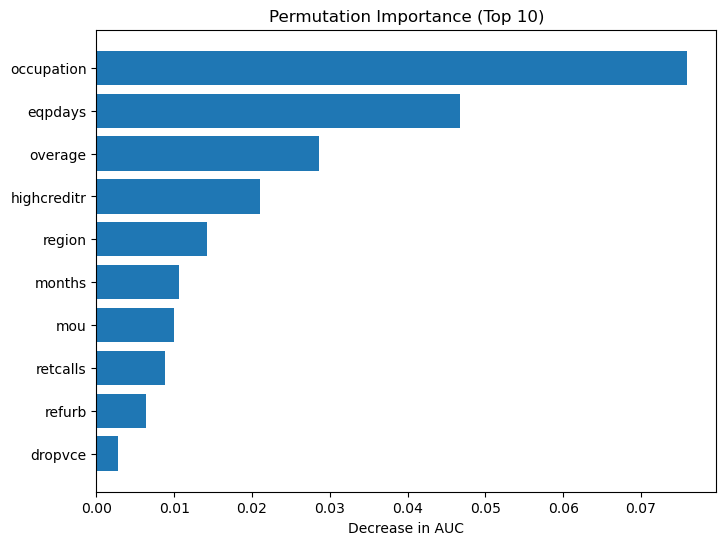

In [78]:
import matplotlib.pyplot as plt

sorted_items = sorted(
    perm_dict.items(),
    key=lambda x: x[1],
    reverse=True
)

top_n = 10
features = [x[0] for x in sorted_items[:top_n]]
values = [x[1] for x in sorted_items[:top_n]]

plt.figure(figsize=(8,6))
plt.barh(features[::-1], values[::-1])
plt.xlabel("Decrease in AUC")
plt.title("Permutation Importance (Top 10)")
plt.show()

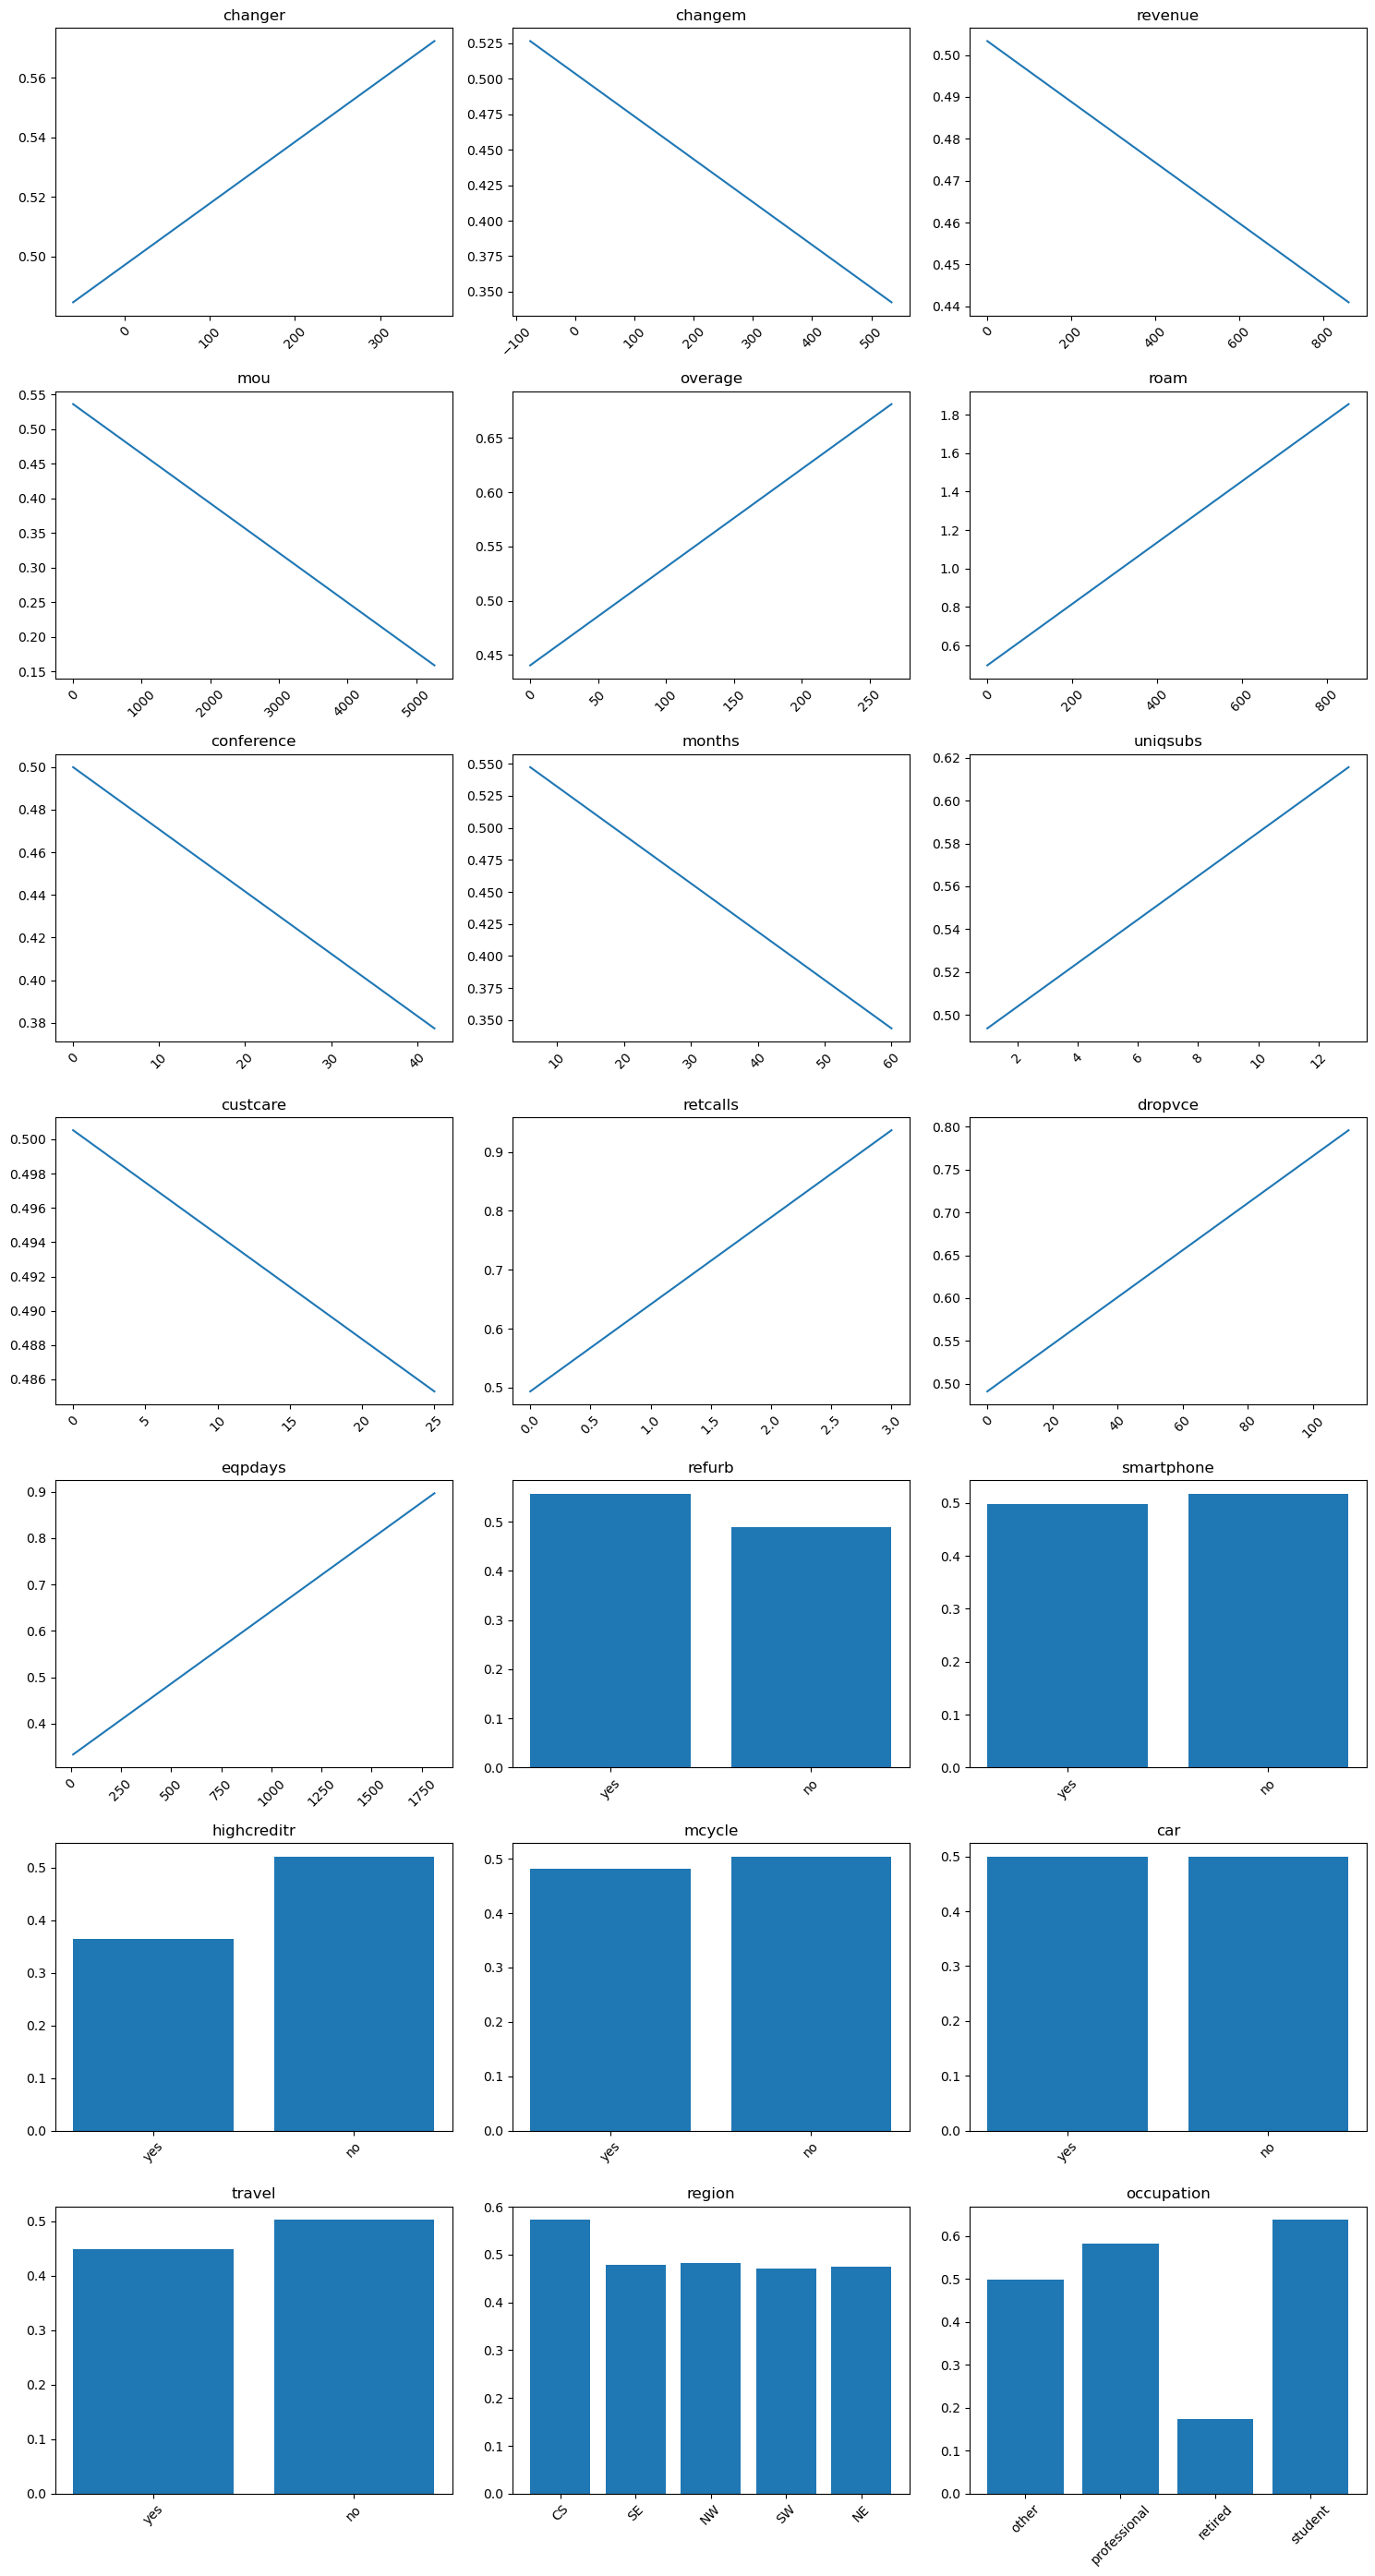

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import math

exclude_cols = ["customer", "churn", "training", "representative", "churn_num"]
features = [c for c in valid.columns if c not in exclude_cols]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    
    if valid[feature].dtype in [pl.Int32, pl.Int64, pl.Float32, pl.Float64]:
        values = np.linspace(valid[feature].min(), valid[feature].max(), 20)
    else:
        values = valid[feature].unique().to_list()

    pd_values = []

    for val in values:
        data_temp = valid.with_columns(
            pl.lit(val).alias(feature)
        )
        pred = logit_reduced.predict(data_temp)["prediction"].mean()
        pd_values.append(pred)

    ax = axes[i]

    if isinstance(values[0], (int, float, np.number)):
        ax.plot(values, pd_values)
    else:
        ax.bar(values, pd_values)

    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Top 5 Drivers of Customer Churn

Drivers are selected based on a combination of:
- High permutation importance (largest decrease in validation AUC)
- Statistically significant coefficients in the logistic model
- Clear and stable patterns in Partial Dependence Plots (PDP)

1. Occupation  
The strongest overall driver. Students and professionals show substantially higher churn risk than retired customers.

2. Equipment Age (eqpdays)  
Older devices are strongly associated with higher churn probability, indicating upgrade cycles drive switching behavior.

3. Overage Usage  
Higher overage minutes significantly increase churn risk, suggesting dissatisfaction with pricing or plan mismatch.

4. Credit Rating (highcreditr)  
Lower credit rating customers exhibit materially higher churn probability, reflecting lower retention stability.

5. Tenure (months)  
Longer-tenure customers are significantly less likely to churn, indicating increasing loyalty over time.

#### Q3 Action Plan Based on Key Churn Drivers

The model results indicate that churn risk is primarily driven by device lifecycle effects, pricing-plan mismatch, and customer segmentation characteristics. The recommended actions therefore focus on areas where predictive impact is strong and managerial intervention is feasible.

Device age (eqpdays) stands out as one of the most influential predictors. Customers with older handsets exhibit substantially higher churn probability, suggesting that switching behavior is closely tied to handset replacement cycles. This implies that S-Mobile should proactively approach customers with aging devices through early upgrade incentives, trade-in programs, or renewal bundles before competitive switching is triggered.

Overage usage is another key driver of churn, likely reflecting dissatisfaction with plan fit or unexpected billing charges. This creates an opportunity for proactive plan optimization. Automated plan recommendations, usage alerts, and targeted adjustments for heavy overage users could reduce billing friction and improve perceived fairness, thereby lowering churn risk.

Customer segmentation variables such as occupation also reveal meaningful structural differences in churn behavior. Students and professionals display significantly higher churn risk compared to retirees, indicating that retention strategies should be segment-specific. Flexible student plans, professional bundles, and lifecycle-aligned communication may reduce attrition in these high-risk groups.

Credit rating further differentiates churn propensity, with lower-credit customers showing elevated risk. Introducing flexible payment options, installment structures, or auto-payment incentives may help mitigate financial stress-related churn in this segment.

Tenure exhibits a protective effect, as longer-tenure customers are less likely to churn. This supports the implementation of milestone-based loyalty programs and renewal incentives designed to reinforce retention before customers reach potential switching windows.

Overall, the evidence suggests that effective churn reduction should concentrate on proactive upgrade timing, plan alignment, targeted segmentation strategies, and financial flexibility. These initiatives directly address the strongest predictive signals identified in the analysis and provide clear pathways for managerial intervention.

#### Q4

In [83]:
# Baseline calibrated probabilities
baseline_mean = p_corrected.mean()
baseline_mean

np.float64(0.019913981316691774)

In [84]:
rep_eqp = rep.with_columns(
    pl.when(pl.col("eqpdays") > 700)
    .then(100)
    .otherwise(pl.col("eqpdays"))
    .alias("eqpdays")
)

pred_eqp = logit_reduced.predict(rep_eqp)

p_eqp = pred_eqp["prediction"].to_numpy()
p_eqp = np.clip(p_eqp, 1e-10, 1-1e-10)

logit_vals = np.log(p_eqp / (1 - p_eqp))
logit_corrected = logit_vals + adjustment
p_eqp_corrected = 1 / (1 + np.exp(-logit_corrected))

impact_eqp = baseline_mean - p_eqp_corrected.mean()
impact_eqp

np.float64(0.0034760545239340204)

In [85]:
rep_over = rep.with_columns(
    pl.when(pl.col("overage") > 100)
    .then(20)
    .otherwise(pl.col("overage"))
    .alias("overage")
)

pred_over = logit_reduced.predict(rep_over)

p_over = pred_over["prediction"].to_numpy()
p_over = np.clip(p_over, 1e-10, 1-1e-10)

logit_vals = np.log(p_over / (1 - p_over))
logit_corrected = logit_vals + adjustment
p_over_corrected = 1 / (1 + np.exp(-logit_corrected))

impact_over = baseline_mean - p_over_corrected.mean()
impact_over

np.float64(0.003089283695176189)

In [87]:
rep_occ = rep.with_columns(
    pl.when(pl.col("occupation") == "student")
    .then(pl.lit("professional"))
    .otherwise(pl.col("occupation"))
    .alias("occupation")
)

pred_occ = logit_reduced.predict(rep_occ)

p_occ = pred_occ["prediction"].to_numpy()
p_occ = np.clip(p_occ, 1e-10, 1-1e-10)

logit_vals = np.log(p_occ / (1 - p_occ))
logit_corrected = logit_vals + adjustment
p_occ_corrected = 1 / (1 + np.exp(-logit_corrected))

impact_occ = baseline_mean - p_occ_corrected.mean()
impact_occ

np.float64(0.0004294969940822277)

In [89]:
rep_credit = rep.with_columns(
    pl.when(pl.col("highcreditr") == "no")
    .then(pl.lit("yes"))
    .otherwise(pl.col("highcreditr"))
    .alias("highcreditr")
)

pred_credit = logit_reduced.predict(rep_credit)

p_credit = pred_credit["prediction"].to_numpy()
p_credit = np.clip(p_credit, 1e-10, 1-1e-10)

logit_vals = np.log(p_credit / (1 - p_credit))
logit_corrected = logit_vals + adjustment
p_credit_corrected = 1 / (1 + np.exp(-logit_corrected))

impact_credit = baseline_mean - p_credit_corrected.mean()
impact_credit

np.float64(0.008801545184936008)

In [90]:
rep_drop = rep.with_columns(
    pl.when(pl.col("dropvce") > 10)
    .then(pl.lit(2))
    .otherwise(pl.col("dropvce"))
    .alias("dropvce")
)

pred_drop = logit_reduced.predict(rep_drop)

p_drop = pred_drop["prediction"].to_numpy()
p_drop = np.clip(p_drop, 1e-10, 1-1e-10)

logit_vals = np.log(p_drop / (1 - p_drop))
logit_corrected = logit_vals + adjustment
p_drop_corrected = 1 / (1 + np.exp(-logit_corrected))

impact_drop = baseline_mean - p_drop_corrected.mean()
impact_drop

np.float64(0.00016538402395325016)

In [91]:
{
    "Baseline churn rate": baseline_mean,
    "Early upgrade impact": impact_eqp,
    "Plan optimization impact": impact_over,
    "Student offer impact": impact_occ,
    "Credit auto-pay impact": impact_credit,
    "Service quality impact": impact_drop
}

{'Baseline churn rate': np.float64(0.019913981316691774),
 'Early upgrade impact': np.float64(0.0034760545239340204),
 'Plan optimization impact': np.float64(0.003089283695176189),
 'Student offer impact': np.float64(0.0004294969940822277),
 'Credit auto-pay impact': np.float64(0.008801545184936008),
 'Service quality impact': np.float64(0.00016538402395325016)}

##### Impact of Actionable Interventions on Churn Probability

The baseline predicted churn rate in the representative sample is approximately **1.99%**, which is consistent with the actual population churn rate.

Among the evaluated interventions:

- **Credit auto-pay enrollment** generates the largest reduction, decreasing churn by approximately **0.88 percentage points**.
- **Early device upgrade program** reduces churn by about **0.35 percentage points**.
- **Plan optimization (reducing overage exposure)** lowers churn by roughly **0.31 percentage points**.
- **Student-targeted retention offer** produces a modest impact of around **0.04 percentage points**.
- **Service quality improvement (reducing dropped calls)** has a small but positive effect of approximately **0.02 percentage points**.

Overall, financially anchored and commitment-based interventions (e.g., credit auto-pay, upgrade programs) deliver the strongest impact, while usage-related adjustments show comparatively smaller marginal effects. These probability reductions can now be translated into economic value through CLV analysis.

##### Experimental Design (RCT) to Evaluate Retention Interventions

Although the impact of the proposed actions was estimated using model-based counterfactual predictions, a randomized controlled trial (RCT) would be required to validate their real-world effectiveness.

To evaluate each intervention (e.g., credit auto-pay enrollment, early upgrade offer, plan optimization, student-targeted offer, and service quality improvement), the following experimental setup is recommended:

Customers in the representative sample would first be ranked by predicted churn probability. High-risk customers would then be randomly assigned into two groups:

- **Treatment group**: receives the specific intervention (e.g., auto-pay incentive).
- **Control group**: receives no intervention.

Random assignment ensures causal identification of the intervention effect. The experiment would run for one billing cycle (or multiple cycles if needed), and the observed churn rates between treatment and control groups would be compared.

The treatment effect would be measured as:

Churn Reduction = Churn Rate (control) − Churn Rate (treatment)

If the observed reduction is consistent with the model-predicted probability decrease (e.g., ~0.88 percentage points for credit auto-pay), the intervention can be scaled across the high-risk segment.

Because full RCT deployment may be costly or operationally constrained, the model-based estimates provide a reasonable first approximation. However, before large-scale rollout, at least a pilot experiment should be conducted to confirm:

- Statistical significance of churn reduction  
- Economic viability after accounting for incentive costs  
- No unintended behavioral side effects  

The combination of predictive modeling and controlled experimentation ensures both analytical rigor and practical decision support.

#### Q5 Targeting Strategy: Which Action to Offer to Which Customers

The five interventions should not be applied to all customers. Instead, actions will be targeted to high-risk customers whose characteristics align with the specific churn driver. This improves cost efficiency and maximizes return on investment.

##### Early Upgrade Offer (Device Age – eqpdays)

**Target group:**  
Customers in the top churn-risk segment (e.g., top 20%) with high handset age (above the 75th percentile).

**Rationale:**  
Older devices are associated with higher churn. Offering upgrades only to high-risk customers reduces unnecessary subsidy costs.

##### Plan Optimization (Overage Usage)

**Target group:**  
High churn-risk customers with consistently high overage usage.

**Rationale:**  
Frequent overage may cause bill dissatisfaction. Recommending better-fitting plans reduces financial frustration and churn risk.

##### Student Retention Offer (Occupation)

**Target group:**  
Students with above-median predicted churn probability.

**Rationale:**  
Students exhibit the highest churn rates. Targeted discounts or flexible plans may significantly reduce churn in this segment.

##### Credit Auto-Pay Incentive (Credit Rating)

**Target group:**  
Customers without high credit rating and with high predicted churn probability.

**Rationale:**  
Lower credit customers churn more frequently. Incentivizing auto-pay strengthens commitment and improves retention.

##### Service Quality Intervention (Dropped Calls – dropvce)

**Target group:**  
High churn-risk customers experiencing frequent dropped calls.

**Rationale:**  
Service instability increases dissatisfaction. Proactive technical support or network prioritization directly addresses this driver.

##### Targeting Principle

Interventions are applied only to high predicted churn customers within driver-relevant segments, rather than to the entire customer base. This ensures budget efficiency, higher expected churn reduction per dollar spent, and alignment between churn drivers and intervention design.

#### Q6

In [92]:
import numpy as np

m = 40                    # monthly cost
c_base = 0.02             # baseline churn
d = 0.10 / 12             # monthly discount
T = 60                   

In [93]:
def compute_clv(m, c, d, T):
    r = 1 - c
    q = r / (1 + d)
    clv = (m / (1 + d)) * ((1 - q**T) / (1 - q))
    return clv

In [94]:
CLV_base = compute_clv(m, c_base, d, T)
CLV_base

1156.4478981403204

In [95]:
delta_upgrade = impact_eqp
delta_plan = impact_over
delta_credit = impact_credit

In [96]:
# Early Upgrade
CLV_upgrade = compute_clv(m, c_base - delta_upgrade, d, T)
delta_CLV_upgrade = CLV_upgrade - CLV_base

# Plan Optimization
CLV_plan = compute_clv(m, c_base - delta_plan, d, T)
delta_CLV_plan = CLV_plan - CLV_base

# Credit Auto-pay
CLV_credit = compute_clv(m, c_base - delta_credit, d, T)
delta_CLV_credit = CLV_credit - CLV_base

CLV_base, delta_CLV_upgrade, delta_CLV_plan, delta_CLV_credit

(1156.4478981403204,
 np.float64(92.83495624898546),
 np.float64(81.96030924183242),
 np.float64(258.1822196338062))

In [97]:
{
    "Baseline CLV": CLV_base,
    "Upgrade Breakeven": delta_CLV_upgrade,
    "Plan Breakeven": delta_CLV_plan,
    "Credit Breakeven": delta_CLV_credit
}

{'Baseline CLV': 1156.4478981403204,
 'Upgrade Breakeven': np.float64(92.83495624898546),
 'Plan Breakeven': np.float64(81.96030924183242),
 'Credit Breakeven': np.float64(258.1822196338062)}

The baseline 5-year CLV per customer is approximately **$1,156**, based on the representative churn rate (2%) and the assumed discount rate.

Using the estimated churn reductions from Step 4, the incremental CLV (breakeven cost) for each action is:

- **Credit Auto-pay:** +$258 per customer  
- **Early Upgrade:** +$93 per customer  
- **Plan Optimization:** +$82 per customer  

These values represent the **maximum cost per targeted customer** at which the firm would be economically indifferent between the status quo and implementing the action.

##### Proposed Cost Assumptions

To ensure profitability, implementation costs should remain below the breakeven values:

- Credit Auto-pay incentive: **$40–$60 per customer**
- Early device upgrade subsidy: **$50–$70 per customer**
- Plan optimization promotion: **$30–$50 per customer**

Under these assumptions:

- Credit Auto-pay delivers the highest economic return due to its large CLV buffer.
- Early Upgrade provides moderate but positive long-term value.
- Plan Optimization remains profitable but is more cost-sensitive.

##### Strategic Implication

Credit Auto-pay should be prioritized as the primary retention strategy due to its strong economic leverage. Early Upgrade and Plan Optimization can be selectively deployed to high-risk customers to maximize return on investment.

Overall, all three actions generate positive long-term value under realistic cost assumptions, but their profitability differs substantially, making targeted deployment essential.